# Classificacao de Sons Respiratorios com EfficientNet-B0

Este notebook implementa um pipeline completo para classificar sons respiratorios a partir de espectrogramas mel 128x128.
O fluxo cobre: montagem do dataset, validacoes de integridade, treinamento em duas etapas, avaliacao por paciente e salvamento dos artefatos.
A ideia central e aprender um classificador robusto que generalize no nivel de paciente, nao apenas no nivel de ciclo.

In [1]:
from pathlib import Path
import json
import random

import numpy as np
import pandas as pd

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, confusion_matrix, f1_score, classification_report
 )

import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!ls /content/drive/MyDrive/processed_audio/

101  111  121  131  141  151  161  171	181  191  201  211  221
102  112  122  132  142  152  162  172	182  192  202  212  222
103  113  123  133  143  153  163  173	183  193  203  213  223
104  114  124  134  144  154  164  174	184  194  204  214  224
105  115  125  135  145  155  165  175	185  195  205  215  225
106  116  126  136  146  156  166  176	186  196  206  216  226
107  117  127  137  147  157  167  177	187  197  207  217  metadata.csv
108  118  128  138  148  158  168  178	188  198  208  218  models
109  119  129  139  149  159  169  179	189  199  209  219
110  120  130  140  150  160  170  180	190  200  210  220


In [4]:
!zip -r /content/drive/MyDrive/processed_audio.zip /content/drive/MyDrive/processed_audio

Streaming output truncated to the last 5000 lines.
  adding: content/drive/MyDrive/processed_audio/139/139_1b1_Ar_sc_Litt3200_cycle_7.npy (deflated 68%)
  adding: content/drive/MyDrive/processed_audio/139/139_1b1_Pr_sc_Litt3200_cycle_0.npy (deflated 73%)
  adding: content/drive/MyDrive/processed_audio/139/139_1b1_Ll_sc_Litt3200_cycle_7.npy (deflated 64%)
  adding: content/drive/MyDrive/processed_audio/139/139_1b1_Pl_sc_Litt3200_cycle_2.npy (deflated 77%)
  adding: content/drive/MyDrive/processed_audio/139/139_1b1_Pr_sc_Litt3200_cycle_4.npy (deflated 72%)
  adding: content/drive/MyDrive/processed_audio/139/139_1b1_Al_sc_Litt3200_cycle_4.npy (deflated 79%)
  adding: content/drive/MyDrive/processed_audio/139/139_1b1_Pl_sc_Litt3200_cycle_3.npy (deflated 72%)
  adding: content/drive/MyDrive/processed_audio/139/139_1b1_Ar_sc_Litt3200_cycle_8.npy (deflated 85%)
  adding: content/drive/MyDrive/processed_audio/139/139_1b1_Lr_sc_Litt3200_cycle_5.npy (deflated 78%)
  adding: content/drive/MyDrive

In [ ]:
#!rsync -a /content/drive/MyDrive/processed_audio/ /content/processed_audio/

In [8]:
!ls /content/drive/MyDrive/

'08 - Geral.xlsx'
'10 bullet points (1).gdoc'
'10 bullet points.gdoc'
 1984.gdoc
'1o PDI.gdoc'
 2006f9dd-8df8-4d4a-9088-90f103b72f6b.MP4
'2021.1 - Janeiro - Termo de Adesão Voluntariado - Trabalho Voluntário (1).docx'
'2021.1 - Janeiro - Termo de Adesão Voluntariado - Trabalho Voluntário.docx'
'2D_Atividade de classe_1o trimestre.gdoc'
 2D_Fellipe_Guilherme_Isabela_Luisa_ManuelaS.gdoc
'A ascensão dos dados e das Big Techs.gslides'
'Ac 9 Guerra civil China.gdoc'
'ACTIVIDADES 18 3.gdoc'
 AI_in_Medicine
'ajustes gamificacao 13 11.gdoc'
'algum post 1.png'
'algum post 2.png'
'Alocação 2ª fase 2025.1.gsheet'
'americanah c6.gdoc'
'Analise foto 2.gdoc'
'Análise peça publicitária.gdoc'
'Análise PI.gdoc'
 analise_texto
'Anotaciones Estados Autoritarios.gdoc'
'anotacoes aula de inv fis.gdoc'
'anotacoes banca intermediaria.gdoc'
'anotacoes entendimento.gdoc'
'Anotacoes entrevista.gdoc'
'anotacoes kickoff gamificacao.gdoc'
'anotacoes mentoria capstone.gdoc'
'anotacoes reuniao.gdoc'
'anot

In [5]:
!cp /content/drive/MyDrive/processed_audio.zip /content/
!unzip -q /content/processed_audio.zip -d /content/

In [9]:
!cp /content/drive/MyDrive/processed_audio.zip /content/

In [13]:
!unzip -q /content/processed_audio.zip -d /content/

replace /content/content/drive/MyDrive/processed_audio/metadata.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A

A


In [19]:
!ls /content/

content  drive	processed_audio  processed_audio.zip  sample_data


In [17]:
!mv /content/content/drive/MyDrive/processed_audio /content/

In [18]:
!ls /content/processed_audio/

101  111  121  131  141  151  161  171	181  191  201  211  221
102  112  122  132  142  152  162  172	182  192  202  212  222
103  113  123  133  143  153  163  173	183  193  203  213  223
104  114  124  134  144  154  164  174	184  194  204  214  224
105  115  125  135  145  155  165  175	185  195  205  215  225
106  116  126  136  146  156  166  176	186  196  206  216  226
107  117  127  137  147  157  167  177	187  197  207  217  metadata.csv
108  118  128  138  148  158  168  178	188  198  208  218  models
109  119  129  139  149  159  169  179	189  199  209  219
110  120  130  140  150  160  170  180	190  200  210  220


## 1) Carregar metadados e validar caminhos dos espectrogramas
Ler processed_audio/metadata.csv e garantir que as colunas essenciais existem (paciente, diagnostico, split e caminho do espectrograma).
Remover registros com valores nulos ou strings vazias para evitar erros silenciosos no treino.
Construir caminhos absolutos dos .npy e checar existencia real dos arquivos antes de seguir.
Se houver arquivos ausentes, interromper aqui para corrigir o dataset, evitando treinos com entradas quebradas.

In [21]:
from pathlib import Path
import pandas as pd

project_root = Path("/content")
metadata_path = Path("/content/processed_audio/metadata.csv")

df = pd.read_csv(metadata_path)

required_cols = [
    "patient_id",
    "spectrogram_path",
    "diagnosis",
    "split",
    "crackles",
    "wheezes",
]

missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

df = df.copy()

# Remove nulos antes de converter para string
df = df.dropna(subset=["patient_id", "spectrogram_path", "diagnosis", "split"])

df["diagnosis"] = df["diagnosis"].astype(str).str.strip()
df["split"] = df["split"].astype(str).str.strip()
df["spectrogram_path"] = df["spectrogram_path"].astype(str).str.strip()

# Remove linhas vazias ou inválidas
df = df[(df["diagnosis"] != "") & (df["diagnosis"].str.lower() != "nan")]

# Resolve caminhos relativos a partir da pasta processed_audio
df["spec_path_abs"] = df["spectrogram_path"].map(lambda p: (project_root / p).resolve())
missing_paths = df[~df["spec_path_abs"].map(lambda p: p.exists())]
if not missing_paths.empty:
    raise FileNotFoundError(
        f"Missing spectrogram files. Examples: {missing_paths['spectrogram_path'].head(5).tolist()}"
    )

print("Metadata rows:", len(df))
print("Project root:", project_root)

Metadata rows: 6898
Project root: /content


## 2) Construir splits no nivel de paciente a partir dos metadados
Separar o dataset em train/validation/test usando a coluna split ja definida no metadata.
Conferir se cada split tem exemplos; se algum estiver vazio, o treino fica invalido.
Checar vazamento de pacientes entre splits para evitar data leakage e inflacao artificial de metricas.
Reportar o tamanho de cada split para ter um diagnostico rapido da distribuicao.

In [22]:
splits = ['train', 'validation', 'test']
df_splits = {s: df[df['split'] == s].copy() for s in splits}
for s in splits:
    if df_splits[s].empty:
        raise ValueError(f'No samples found for split: {s}')

split_counts = df[['patient_id', 'split']].drop_duplicates().groupby('patient_id')['split'].nunique()
leaky_patients = split_counts[split_counts > 1]
print('Patients appearing in multiple splits:', len(leaky_patients))
if len(leaky_patients) > 0:
    display(leaky_patients.head(10))

print('Train/Val/Test sizes:', {k: len(v) for k, v in df_splits.items()})

Patients appearing in multiple splits: 0
Train/Val/Test sizes: {'train': 4503, 'validation': 1288, 'test': 1107}


## 3) Codificacao de labels e mapeamento de classes
Transformar cada diagnostico textual em um indice inteiro usando LabelEncoder.
Criar o mapeamento label->indice e indice->label para treinar o modelo e interpretar previsoes depois.
Reaplicar os splits com a coluna label ja criada para manter coerencia em todo o pipeline.
Exibir o mapeamento para documentar claramente a ordem das classes.

In [23]:
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['diagnosis'])
label_mapping = {label: int(idx) for idx, label in enumerate(label_encoder.classes_)}
inv_label_mapping = {int(idx): label for label, idx in label_mapping.items()}
df_splits = {s: df[df['split'] == s].copy() for s in splits}

display(pd.DataFrame({'label': list(label_mapping.keys()), 'index': list(label_mapping.values())}))

,label,index
0,Bronchiectasis,0
1,Bronchiolitis,1
2,COPD,2
3,Healthy,3
4,Other,4
5,Pneumonia,5
6,URTI,6


## 4) Dataset: carregamento sob demanda de .npy e pre-processamento
Definir funcoes de normalizacao e conversao de shape para garantir entrada consistente ao modelo.
Carregar cada espectrograma sob demanda (lazy loading) para economizar memoria em datasets grandes.
Normalizar os valores para a faixa [0,1] e garantir que o shape final seja 3x128x128.
Converter para tensor e retornar tambem o id do paciente para agregacao posterior.

In [24]:
def normalize_spectrogram(arr: np.ndarray) -> np.ndarray:
    arr = arr.astype(np.float32)
    arr_min = arr.min()
    arr_max = arr.max()
    return (arr - arr_min) / (arr_max - arr_min + 1e-6)

def to_3ch_tensor(arr: np.ndarray) -> torch.Tensor:
    if arr.shape == (128, 128):
        arr = np.expand_dims(arr, axis=0)
    elif arr.shape == (128, 128, 1):
        arr = np.transpose(arr, (2, 0, 1))
    if arr.shape != (1, 128, 128):
        raise ValueError(f'Unexpected spectrogram shape: {arr.shape}')
    arr = np.repeat(arr, 3, axis=0)
    return torch.from_numpy(arr)

class SpectrogramDataset(Dataset):
    def __init__(self, df_split: pd.DataFrame, *, training: bool, augment_fn=None):
        self.df = df_split.reset_index(drop=True)
        self.training = training
        self.augment_fn = augment_fn

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        arr = np.load(row['spec_path_abs'], allow_pickle=False)
        arr = normalize_spectrogram(arr)
        if self.training and self.augment_fn is not None:
            arr = self.augment_fn(arr)
        tensor = to_3ch_tensor(arr)
        label = int(row['label'])
        pid = row['patient_id']
        return tensor, label, pid

## 5) Aumento de dados: SpecAugment (somente treino)
Aplicar mascaras aleatorias em tempo e frequencia para simular variacoes naturais do audio.
Isso ajuda a reduzir overfitting e melhora a generalizacao do modelo.
As augmentations sao aplicadas apenas no treino para nao distorcer validacao/teste.
Parametros leves (mascaras pequenas) preservam estrutura principal do espectrograma.

In [25]:
def spec_augment(arr: np.ndarray, time_mask_max=12, freq_mask_max=12) -> np.ndarray:
    aug = arr.copy()
    freq_len, time_len = aug.shape[-2], aug.shape[-1]
    if time_len > 1:
        t = np.random.randint(0, min(time_mask_max, time_len))
        t0 = np.random.randint(0, max(1, time_len - t))
        aug[..., t0:t0 + t] = 0.0
    if freq_len > 1:
        f = np.random.randint(0, min(freq_mask_max, freq_len))
        f0 = np.random.randint(0, max(1, freq_len - f))
        aug[..., f0:f0 + f, :] = 0.0
    return aug

## 6) Dataloaders e collation
Configurar batch size e num_workers dependendo da disponibilidade de GPU.
Criar DataLoaders para treino, validacao e teste com pin_memory para acelerar transferencia.
Embaralhar apenas o treino para garantir aleatoriedade; manter ordem em validacao/teste.
Exibir o numero de batches para checagem rapida de tamanho do dataset.

In [26]:
batch_size = 32 if torch.cuda.is_available() else 16
num_workers = 2 if torch.cuda.is_available() else 0

train_ds = SpectrogramDataset(df_splits['train'], training=True, augment_fn=spec_augment)
val_ds = SpectrogramDataset(df_splits['validation'], training=False, augment_fn=None)
test_ds = SpectrogramDataset(df_splits['test'], training=False, augment_fn=None)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=torch.cuda.is_available())

print('Batches (train/val/test):', len(train_loader), len(val_loader), len(test_loader))

Batches (train/val/test): 141 41 35


## 7) Modelo: backbone EfficientNet-B0 + cabeca de classificacao
Carregar pesos locais se estiverem disponiveis para evitar download e acelerar setup.
Caso contrario, usar pesos pre-treinados da EfficientNet-B0 como ponto de partida.
Substituir a cabeca final por um linear com o numero exato de classes do dataset.
Mover o modelo para GPU/CPU conforme o device detectado.

In [27]:
import ssl
import certifi

ssl._create_default_https_context = ssl.create_default_context
ssl._create_default_https_context = ssl.create_default_context(cafile=certifi.where())

In [28]:
num_classes = len(label_encoder.classes_)
local_weights_path = project_root / 'processed_audio' / 'models' / 'efficientnet_b0_rwightman-7f5810bc.pth'

if local_weights_path.exists():
    model = torchvision.models.efficientnet_b0(weights=None)
    state = torch.load(local_weights_path, map_location='cpu')
    if isinstance(state, dict) and 'state_dict' in state:
        state = state['state_dict']
    cleaned_state = {
        k.replace('module.', '').replace('model.', ''): v for k, v in state.items()
    }
    missing, unexpected = model.load_state_dict(cleaned_state, strict=False)
    print('Loaded local weights:', local_weights_path)
    print('Missing keys:', len(missing), 'Unexpected keys:', len(unexpected))
else:
    weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT
    model = torchvision.models.efficientnet_b0(weights=weights)

in_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(in_features, num_classes)
 )
model = model.to(device)
print(model.classifier)

Loaded local weights: /content/processed_audio/models/efficientnet_b0_rwightman-7f5810bc.pth
Missing keys: 0 Unexpected keys: 0
Sequential(
  (0): Dropout(p=0.4, inplace=False)
  (1): Linear(in_features=1280, out_features=7, bias=True)
)


## 8) Loss, otimizador e metricas
Usar Focal Loss para reduzir o impacto de classes dominantes e focar em exemplos dificeis.
Configurar AdamW com weight decay para melhorar generalizacao.
Definir funcao de metricas por paciente para refletir o objetivo clinico.
Manter a avaliacao no nivel de paciente, nao apenas no nivel de ciclo.

In [29]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, reduction='mean'):
        super().__init__()
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        logp = nn.functional.log_softmax(logits, dim=1)
        p = torch.exp(logp)
        pt = p.gather(1, targets.unsqueeze(1)).squeeze(1)
        loss = -(1 - pt) ** self.gamma * logp.gather(1, targets.unsqueeze(1)).squeeze(1)
        if self.reduction == 'mean':
            return loss.mean()
        if self.reduction == 'sum':
            return loss.sum()
        return loss

criterion = FocalLoss(gamma=2.0)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

def compute_patient_metrics(results_df, label_order):
    y_true = results_df['true_label'].values
    y_pred = results_df['pred_label'].values
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0
    )
    cm = confusion_matrix(y_true, y_pred, labels=label_order)
    return acc, precision, recall, f1, cm

## 9) Treino etapa 1: backbone congelado
Congelar o backbone para treinar apenas a cabeca final inicialmente.
Isso estabiliza o treino e permite ajustar o classificador rapido com poucas epocas.
Aplicar early stopping baseado no F1 macro por paciente para evitar overfitting.
Salvar o melhor checkpoint desta etapa para comparacao posterior.

In [30]:
def predict_cycle_probs(model, loader):
    model.eval()
    all_probs = []
    all_labels = []
    all_pids = []
    with torch.no_grad():
        for xb, yb, pids in loader:
            xb = xb.to(device)
            logits = model(xb)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            all_probs.append(probs)
            all_labels.append(yb.numpy())
            all_pids.extend(pids)
    probs = np.concatenate(all_probs, axis=0)
    labels = np.concatenate(all_labels, axis=0)
    cycle_df = pd.DataFrame(probs, columns=label_encoder.classes_)
    cycle_df['patient_id'] = all_pids
    cycle_df['true_label'] = label_encoder.inverse_transform(labels)
    return cycle_df

def aggregate_patient_results(cycle_df):
    patient_probs = cycle_df.groupby('patient_id')[label_encoder.classes_].mean()
    patient_true = cycle_df.groupby('patient_id')['true_label'].agg(lambda x: x.iloc[0])
    patient_pred = patient_probs.idxmax(axis=1)
    patient_results = pd.DataFrame({
        'patient_id': patient_probs.index,
        'true_label': patient_true.values,
        'pred_label': patient_pred.values,
        'max_confidence': patient_probs.max(axis=1).values
    })
    return patient_results

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    for xb, yb, _ in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
    return total_loss / len(loader.dataset)

def evaluate_loss(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for xb, yb, _ in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            total_loss += loss.item() * xb.size(0)
    return total_loss / len(loader.dataset)

def run_training_stage(model, train_loader, val_loader, optimizer, criterion, max_epochs, patience, stage_name, best_ckpt_path):
    history = {'train_loss': [], 'val_loss': [], 'val_f1': []}
    best_f1 = -np.inf
    best_state = None
    patience_left = patience

    for epoch in range(1, max_epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
        val_loss = evaluate_loss(model, val_loader, criterion)
        val_cycle_df = predict_cycle_probs(model, val_loader)
        val_patient_results = aggregate_patient_results(val_cycle_df)
        _, _, _, val_f1, _ = compute_patient_metrics(val_patient_results, label_encoder.classes_)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_f1'].append(val_f1)

        print(f'{stage_name} Epoch {epoch:02d} | train_loss={train_loss:.4f} val_loss={val_loss:.4f} val_f1={val_f1:.4f}')

        if val_f1 > best_f1:
            best_f1 = val_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            torch.save({'model_state': model.state_dict(), 'best_f1': best_f1}, best_ckpt_path)
            patience_left = patience
        else:
            patience_left -= 1
            if patience_left <= 0:
                print('Early stopping triggered.')
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return history, best_f1

from pathlib import Path

for param in model.features.parameters():
    param.requires_grad = False

stage1_ckpt = Path('/content/drive/MyDrive/processed_audio/models/efficientnet_b0_stage1.pt')
stage1_ckpt.parent.mkdir(parents=True, exist_ok=True)

optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3, weight_decay=1e-4)
stage1_history, stage1_best_f1 = run_training_stage(
    model, train_loader, val_loader, optimizer, criterion,
    max_epochs=10, patience=3, stage_name='Stage1', best_ckpt_path=stage1_ckpt
)

Stage1 Epoch 01 | train_loss=0.5291 val_loss=0.4167 val_f1=0.1960
Stage1 Epoch 02 | train_loss=0.4349 val_loss=0.3951 val_f1=0.1532
Stage1 Epoch 03 | train_loss=0.4027 val_loss=0.3904 val_f1=0.1632
Stage1 Epoch 04 | train_loss=0.3944 val_loss=0.3758 val_f1=0.1823
Early stopping triggered.


## 10) Etapa 2 de fine-tuning: descongelar backbone
Descongelar o backbone e continuar o treino com uma taxa de aprendizado menor.
Isso permite ajustar representacoes internas para o dominio de sons respiratorios.
Salvar o melhor checkpoint da etapa 2 e comparar com a etapa 1.
Selecionar o checkpoint com melhor F1 macro em validacao.

In [31]:
from pathlib import Path

for param in model.features.parameters():
    param.requires_grad = True

stage2_ckpt = Path('/content/drive/MyDrive/processed_audio/models/efficientnet_b0_stage2.pt')
stage2_ckpt.parent.mkdir(parents=True, exist_ok=True)

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

stage2_history, stage2_best_f1 = run_training_stage(
    model, train_loader, val_loader, optimizer, criterion,
    max_epochs=15, patience=4, stage_name='Stage2', best_ckpt_path=stage2_ckpt
)

best_stage = 'stage2' if stage2_best_f1 >= stage1_best_f1 else 'stage1'
best_ckpt = stage2_ckpt if best_stage == 'stage2' else stage1_ckpt
ckpt = torch.load(best_ckpt, map_location=device)
model.load_state_dict(ckpt['model_state'])
print('Best checkpoint:', best_ckpt, 'best_f1=', ckpt['best_f1'])

Stage2 Epoch 01 | train_loss=0.3628 val_loss=0.3050 val_f1=0.2052
Stage2 Epoch 02 | train_loss=0.2098 val_loss=0.2908 val_f1=0.1958
Stage2 Epoch 03 | train_loss=0.1290 val_loss=0.3200 val_f1=0.2580
Stage2 Epoch 04 | train_loss=0.0986 val_loss=0.3460 val_f1=0.2949
Stage2 Epoch 05 | train_loss=0.0759 val_loss=0.3627 val_f1=0.3053
Stage2 Epoch 06 | train_loss=0.0487 val_loss=0.3776 val_f1=0.3193
Stage2 Epoch 07 | train_loss=0.0351 val_loss=0.4019 val_f1=0.2644
Stage2 Epoch 08 | train_loss=0.0422 val_loss=0.4566 val_f1=0.2475
Stage2 Epoch 09 | train_loss=0.0319 val_loss=0.3936 val_f1=0.2427
Stage2 Epoch 10 | train_loss=0.0279 val_loss=0.4244 val_f1=0.2885
Early stopping triggered.
Best checkpoint: /content/drive/MyDrive/processed_audio/models/efficientnet_b0_stage2.pt best_f1= 0.31933605763726786


## 11) Inferencia por ciclo e agregacao por paciente
Rodar o modelo para obter probabilidades por ciclo respiratorio em validacao e teste.
Agrupar as probabilidades por paciente e tirar a media para reduzir ruido.
Escolher a classe final do paciente pelo maior valor medio.
Esse passo alinha a avaliacao ao objetivo clinico (decisao por paciente).

In [32]:
val_cycle_df = predict_cycle_probs(model, val_loader)
test_cycle_df = predict_cycle_probs(model, test_loader)

val_patient_results = aggregate_patient_results(val_cycle_df)
test_patient_results = aggregate_patient_results(test_cycle_df)

val_patient_results.head()

,patient_id,true_label,pred_label,max_confidence
0,tensor(101),URTI,Bronchiolitis,0.521809
1,tensor(101),URTI,Bronchiolitis,0.414197
2,tensor(101),URTI,COPD,0.479123
3,tensor(101),URTI,Healthy,0.486317
4,tensor(101),URTI,COPD,0.788722


## 12) Avaliacao: F1 macro, precisao, recall, acuracia e matriz de confusao
Calcular metricas no nivel de paciente para validacao e teste (macro-averaged).
Imprimir relatorios detalhados por classe para identificar erros sistematicos.
Plotar matrizes de confusao para visualizar onde o modelo confunde diagnosticos.
Essas metricas servem como base para comparar ajustes futuros.

Validation patient-level accuracy: 0.8826446280991735
Validation patient-level precision (macro): 0.28471933604043287
Validation patient-level recall (macro): 0.35744280995465827
Validation patient-level F1 (macro): 0.3131285396419238
Test patient-level accuracy: 0.834375
Test patient-level precision (macro): 0.3196273559283819
Test patient-level recall (macro): 0.3788883362402488
Test patient-level F1 (macro): 0.3292650111661029

Validation classification report:
                precision    recall  f1-score   support

Bronchiectasis       0.50      0.83      0.62         6
 Bronchiolitis       0.00      0.00      0.00        27
          COPD       0.97      0.98      0.97      1055
       Healthy       0.38      0.54      0.45        50
         Other       0.00      0.00      0.00         8
     Pneumonia       0.00      0.00      0.00        31
          URTI       0.14      0.15      0.15        33

      accuracy                           0.88      1210
     macro avg       0.28

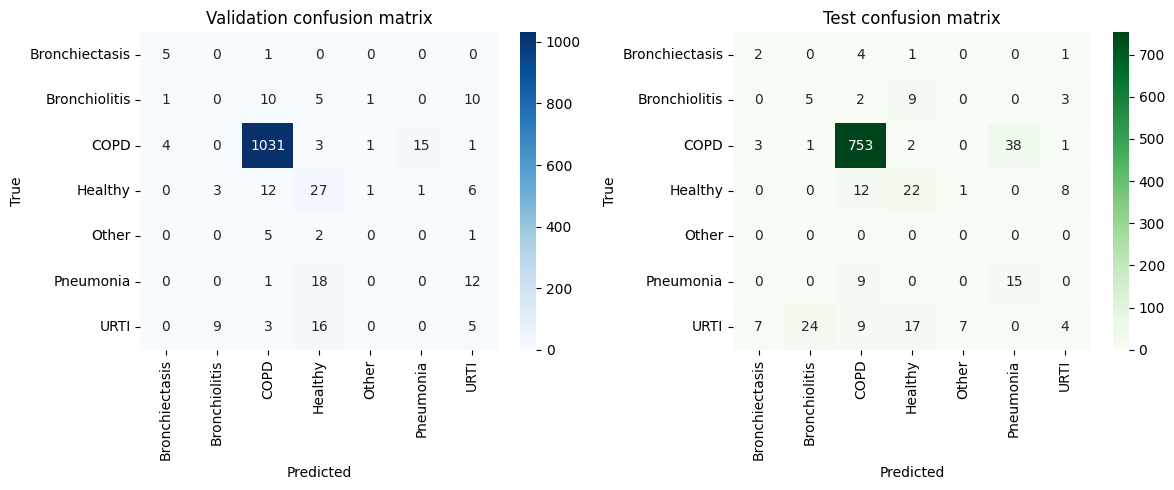

In [33]:
val_acc, val_precision, val_recall, val_f1, val_cm = compute_patient_metrics(
    val_patient_results, label_encoder.classes_
 )
test_acc, test_precision, test_recall, test_f1, test_cm = compute_patient_metrics(
    test_patient_results, label_encoder.classes_
 )

print('Validation patient-level accuracy:', val_acc)
print('Validation patient-level precision (macro):', val_precision)
print('Validation patient-level recall (macro):', val_recall)
print('Validation patient-level F1 (macro):', val_f1)
print('Test patient-level accuracy:', test_acc)
print('Test patient-level precision (macro):', test_precision)
print('Test patient-level recall (macro):', test_recall)
print('Test patient-level F1 (macro):', test_f1)

print('\nValidation classification report:')
print(classification_report(
    val_patient_results['true_label'],
    val_patient_results['pred_label'],
    zero_division=0
 ))

print('Test classification report:')
print(classification_report(
    test_patient_results['true_label'],
    test_patient_results['pred_label'],
    zero_division=0
 ))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(
    val_cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_, ax=axes[0]
 )
axes[0].set_title('Validation confusion matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
sns.heatmap(
    test_cm, annot=True, fmt='d', cmap='Greens',
    xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_, ax=axes[1]
 )
axes[1].set_title('Test confusion matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
plt.tight_layout()
plt.show()

## 13) Curvas de aprendizado e diagnosticos
Plotar perdas de treino e validacao para avaliar convergencia ao longo das epocas.
Plotar F1 macro por etapa para ver ganho real com fine-tuning.
Comparar melhor F1 de cada etapa para decidir o melhor regime de treino.
Usar esses graficos para detectar overfitting ou subtreinamento.

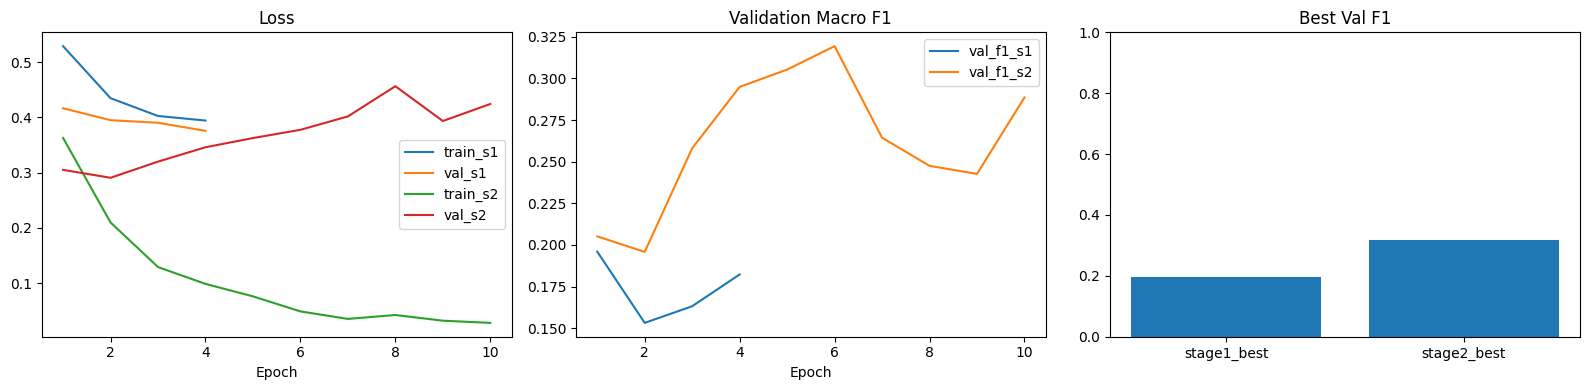

In [34]:
epochs_stage1 = list(range(1, len(stage1_history['train_loss']) + 1))
epochs_stage2 = list(range(1, len(stage2_history['train_loss']) + 1))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(epochs_stage1, stage1_history['train_loss'], label='train_s1')
axes[0].plot(epochs_stage1, stage1_history['val_loss'], label='val_s1')
axes[0].plot(epochs_stage2, stage2_history['train_loss'], label='train_s2')
axes[0].plot(epochs_stage2, stage2_history['val_loss'], label='val_s2')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(epochs_stage1, stage1_history['val_f1'], label='val_f1_s1')
axes[1].plot(epochs_stage2, stage2_history['val_f1'], label='val_f1_s2')
axes[1].set_title('Validation Macro F1')
axes[1].set_xlabel('Epoch')
axes[1].legend()

axes[2].bar(['stage1_best', 'stage2_best'], [stage1_best_f1, stage2_best_f1])
axes[2].set_title('Best Val F1')
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()

## 14) Checkpoints e salvamento de artefatos
Salvar o melhor checkpoint escolhido para reproducao e uso futuro.
Persistir o mapeamento de labels para interpretacao consistente das previsoes.
Registrar metadados do treino (seed, batch size, melhores F1) para rastreabilidade.
Esses arquivos permitem repetir o experimento com os mesmos parametros.

In [35]:
from pathlib import Path

artifacts_dir = Path('/content/drive/MyDrive/processed_audio/artifacts')
artifacts_dir.mkdir(parents=True, exist_ok=True)

label_map_path = artifacts_dir / 'label_mapping.json'
with open(label_map_path, 'w', encoding='utf-8') as f:
    json.dump(label_mapping, f, indent=2)

run_info = {
    'seed': SEED,
    'batch_size': batch_size,
    'stage1_best_f1': float(stage1_best_f1),
    'stage2_best_f1': float(stage2_best_f1),
    'best_checkpoint': str(best_ckpt)
}
run_info_path = artifacts_dir / 'run_info.json'
with open(run_info_path, 'w', encoding='utf-8') as f:
    json.dump(run_info, f, indent=2)

print('Saved label mapping to:', label_map_path)
print('Saved run info to:', run_info_path)

Saved label mapping to: /content/drive/MyDrive/processed_audio/artifacts/label_mapping.json
Saved run info to: /content/drive/MyDrive/processed_audio/artifacts/run_info.json
